In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

c:\Users\chris\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\chris\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
weights = pd.read_csv("original_data/weights1.csv")
weights2 = pd.read_csv("original_data/weights2.csv")
weights = pd.concat([weights, weights2], ignore_index=True)
weights

,OCCURNUM,qstnum,repwgt0,repwgt1,repwgt2,repwgt3,repwgt4,repwgt5,repwgt6,repwgt7,...,repwgt151,repwgt152,repwgt153,repwgt154,repwgt155,repwgt156,repwgt157,repwgt158,repwgt159,repwgt160
0,1,14,18354163,10438492,10407387,28068302,25562833,9239434,25338398,25701567,...,10895492,31037674,9263588,24989376,8651019,23992521,27458755,22802523,26921460,9028737
1,2,14,15592437,8650848,7739514,23599044,22150186,7661903,20928499,24058785,...,9142763,27457903,8064288,19715055,7889177,20023445,24539323,20821892,22804294,7763269
2,1,15,16356249,8971846,7819705,24359971,21130796,8033700,24966868,21950496,...,8970494,22956112,9292178,25490285,7864233,23294925,19066812,23322929,23187256,8032997
3,1,16,20773863,12256987,10094193,28950309,26670581,8927895,30159278,31383567,...,12579129,30210036,11522337,27180683,9795101,25067470,27903109,29132044,28331760,10088447
4,2,16,16796510,9358118,8017431,25625108,24611988,8170753,24141884,24525276,...,9598023,22642743,10367559,21832240,9384531,22057325,25366842,23213102,23656517,8461291
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99058,1,69460,3872403,3811524,3867477,1184134,6392906,3869526,3833685,4185059,...,3946475,3955011,4098830,1141866,7098608,1220946,4046508,6799129,5947367,7015049
99059,1,69461,3872403,3811524,3867477,1184134,6392906,3869526,3833685,4185059,...,3946475,3955011,4098830,1141866,7098608,1220946,4046508,6799129,5947367,7015049
99060,2,69461,3332493,3369042,3339441,1046782,5289272,3467648,3184734,3487858,...,3398154,3455348,3389339,972960,5565823,1068255,3141941,5549270,5110794,5729614
99061,1,69464,2790829,2731309,837142,830413,4724120,5051157,2624563,5274098,...,4617975,2631165,807997,2960079,812894,4881043,2910442,964690,834369,2604438


In [3]:
data = pd.read_csv('original_data/nov24pub_first_half.csv')
data2 = pd.read_csv('original_data/nov24pub_second_half.csv')
data = pd.concat([data, data2], ignore_index=True)
data

,HRHHID,HRMONTH,HRYEAR4,HURESPLI,HUFINAL,FILLER,HETENURE,HEHOUSUT,HETELHHD,HETELAVL,...,PRSUPINT,PES1,PES2,PES3,PES4,PES5,PES6,PES7,PRS8,PESCK4
0,84055620110148,11,2024,-1,219,NaN,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
1,521800504640811,11,2024,1,219,NaN,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
2,510421864001780,11,2024,-1,219,NaN,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
3,7180159540041,11,2024,-1,219,NaN,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
4,71062004118993,11,2024,-1,219,NaN,1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126681,658604017243570,11,2024,-1,218,NaN,2,1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
126682,140784500685805,11,2024,-1,218,NaN,1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
126683,181202500665725,11,2024,1,218,NaN,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
126684,940325328011460,11,2024,1,218,NaN,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1


In [4]:
def filter_rows_by_negative_one_pct(df, threshold=0.2, missing_value=-1, inplace=False):
    # threshold: fraction of cols with missing_value to mark row as bad
    # e.g. 0.5 means ">= 50% of columns are -1"
    bad = (df == missing_value).sum(axis=1) / df.shape[1] >= threshold
    n_bad = int(bad.sum())
    n_total = len(df)
    print(f"{n_bad} rows out of {n_total} have >= {threshold*100:.1f}% of columns == {missing_value}")
    if inplace:
        df.drop(index=df[bad].index, inplace=True)
        print(f"dropped {n_bad} rows, remaining {len(df)} rows")
        return df
    df_clean = df.loc[~bad].reset_index(drop=True)
    print(f"returning cleaned df with {len(df_clean)} rows")
    return df_clean

### USED TO CREATE PRE AND POST DROP COMPARISON PLOTS --- IGNORE ---

# df_clean = filter_rows_by_negative_one_pct(data)

# thresholds = np.linspace(0.0, 1.0, 101)
# remaining_counts = []

# for t in thresholds:
#     df_tmp = filter_rows_by_negative_one_pct(data, threshold=t)
#     remaining_counts.append(len(df_tmp))

# print("data original shape:", data.shape)
# print("rows remaining at thresholds (0..100%):", remaining_counts[:5], "...", remaining_counts[-5:])

# plt.figure(figsize=(8, 5))
# plt.plot(thresholds * 100, remaining_counts, marker="o", markersize=3)
# plt.xlabel("threshold % of columns == -1")
# plt.ylabel("rows remaining")
# plt.title("Rows remaining after filtering at each -1 threshold PreDrop")
# plt.grid(True)
# plt.show()

# plt.figure(figsize=(8, 5))
# plt.hist(remaining_counts, bins=20, edgecolor="k")
# plt.xlabel("rows remaining")
# plt.ylabel("frequency")
# plt.title("Histogram of remaining row counts over thresholds")
# plt.show()


In [5]:
data['HRINTSTA'].value_counts()

# 1 = Interview

# 2 = Type A Noninterview (These records represent households that were eligible
# for the November CPS interview but were not interviewed because no one was
# home, household members were temporarily absent, etc.)

# 3 = Type B Noninterview (These records represent sample addresses determined to
# be ineligible for the CPS by virtue of a temporary situation, such as being
# vacant, nonresidential, etc. These households could become eligible for a CPS
# interview.)

# 4 = Type C Noninterview (These recordsrepresentsample addresses determined to be
# ineligible for CPS by virtue of a permanent change such as demolished,
# condemned, etc. These addresses will not be visited again for CPS interviews.)

# We should only keep rows where HRINTSTA == 1, as these are the only rows that represent actual interviews. The other rows represent non-interviews or ineligible addresses, which are not useful for our analysis.
data = data[data['HRINTSTA'] == 1].reset_index(drop=True)

In [6]:
(data.where(data == -1).count() / len(data) * 100).sort_values(ascending=True).head(90)
# We can also get rid of columns that have a certain percentage of NA values, as these are also likely to be uninformative. 
# We can also get rid of columns that have a certain percentage of 0 values, as these are also likely to be uninformative. 


### Values that have 0% of -1 values (i.e. no missing data)

# HRHHID    HOUSEHOLD IDENTIFIER
# GTCBSA    SPECIFIC METROPOLITAN CBSA CODE  (SEE GEOGRAPHIC ATTACHMENT)
# GTCO      FIPS COUNTY CODE
# GTCBSAST  PRINCIPAL CITY/BALANCE STATUS 
# GTMETSTA  METROPOLITAN STATUS
# GTINDVPC  INDIVIDUAL PRINCIPAL CITY
# GTCBSASZ  Metropolitan Area (CBSA) SIZE (Population)
# GTCSA     Consolidated Statistical Area (CSA) FIPS CODE (SEE GEOGRAPHIC ATTACHMEN
# PTWK      WEEKLY EARNINGS – TOP CODE ****
# PRTFAGE   TOP CODE FLAG FOR AGE **** 
# PWCMPWGT  Composited Final Weight. Used to create BLS's published labor force statistics (4 implied decimal places)
# PTOT      WEEKLY OVERTIME AMOUNT – TOP CODE ****
# GEDIV     DIVISION
# OCCURNUM  Unique person identifier. Valid only within any specific month. 
# HXPHONEO  ALLOCATION FLAG 
# HXTELAVL  ALLOCATION FLAG  
# HXTELHHD  ALLOCATION FLAG
# HXFAMINC  ALLOCATION FLAG
# HXHOUSUT  ALLOCATION FLAG
# HXTENURE  ALLOCATION FLAG
# PWFMWGT   FAMILY WEIGHT (4 IMPLIED DECIMALS) ONLY USED FOR TALLYING FAMILY CHARACTERISTICS.
# PWLGWGT   LONGITUDINAL WEIGHT (4 IMPLIED DECIMALS) ONLY FOUND ON ADULT RECORDS MATCHED FROM MONTH TO MONTH. (USED FOR GROSS FLOWS ANALYSIS)
# PWORWGT   OUTGOING ROTATION WEIGHT (4 IMPLIED DECIMALS) USED FOR TALLYING INFORMATION COLLECTED ONLY IN 
# PWSSWGT   FINAL WEIGHT (4 IMPLIED DECIMAL PLACES) USED FOR MOST TABULATIONS, CONTROLLED TO INDEPENDENT ESTIMATES FOR 1) STATES; 2) ORIGIN, SEX, AND AGE; AND 3) AGE, RA 
# PWVETWGT  VETERANS WEIGHT (4 IMPLIED DECIMALS) USED FOR TALLYING VETERAN'S DATA ONLY, CONTROLLED TO ESTIMATES OF VETERANS SUPPLIED BY
# QSTNUM    Unique household identifier. Valid only within any specific month. 
# GEREG     REGION
# GESTFIPS  STATE CODE
# HUFINAL   FINAL OUTCOME CODE 
# PTHR      HOURLY PAY – TOP CODE ****
# HWHHWGT   HOUSEHOLD WEIGHT (4 IMPLIED DECIMAL PLACES) USED FOR TALLYING HOUSEHOLD CHARACTERISTICS  
# HEPHONEO  IS A TELEPHONE INTERVIEW ACCEPTABLE?
# HRNUMHOU  TOTAL NUMBER OF PERSONS LIVING IN THE HOUSEHOLD (HOUSEHOLD ME
# HRHTYPE   HOUSEHOLD TYPE
# HRMIS     MONTH-IN-SAMPLE 
# HRLONGLK  LONGITUDINAL LINK INDICATOR EDITED UNIVERSE: ALL HHLDs IN SAMPLE 
# HRHHID2   HOUSEHOLD IDENTIFIER (part 2)
# HRYEAR4   YEAR OF INTERVIEW
# HEHOUSUT  TYPE OF HOUSING UNIT
# HRMONTH   MONTH OF INTERVIEW 
# HUPRSCNT  NUMBER OF ACTUAL AND ATTEMPTED PERSONAL CONTACTS

HRHHID       0.000000
QSTNUM       0.000000
OCCURNUM     0.000000
PXDIPGED     0.000000
PXHGCOMP     0.000000
              ...    
HUBUS        0.018170
HUINTTYP     6.536245
PEAFNOW     16.557140
PRIOELG     16.557140
PXCOHAB     16.557140
Length: 90, dtype: float64

In [7]:
for df_name in ['data', 'data2']:
    if df_name in globals():
        df = globals()[df_name]
        keep = ~(df == -1).all(axis=1)
        globals()[df_name] = df.loc[keep].reset_index(drop=True)
        print(f"{df_name}: removed {len(df) - keep.sum()} rows, remaining {keep.sum()}")

data: removed 0 rows, remaining 99063
data2: removed 0 rows, remaining 63343


99063 rows out of 99063 have >= 20.0% of columns == -1
returning cleaned df with 0 rows
99063 rows out of 99063 have >= 0.0% of columns == -1
returning cleaned df with 0 rows
99063 rows out of 99063 have >= 1.0% of columns == -1
returning cleaned df with 0 rows
99063 rows out of 99063 have >= 2.0% of columns == -1
returning cleaned df with 0 rows
99063 rows out of 99063 have >= 3.0% of columns == -1
returning cleaned df with 0 rows
99063 rows out of 99063 have >= 4.0% of columns == -1
returning cleaned df with 0 rows
99063 rows out of 99063 have >= 5.0% of columns == -1
returning cleaned df with 0 rows
99063 rows out of 99063 have >= 6.0% of columns == -1
returning cleaned df with 0 rows
99063 rows out of 99063 have >= 7.0% of columns == -1
returning cleaned df with 0 rows
99063 rows out of 99063 have >= 8.0% of columns == -1
returning cleaned df with 0 rows
99063 rows out of 99063 have >= 9.0% of columns == -1
returning cleaned df with 0 rows
99063 rows out of 99063 have >= 10.0% of c

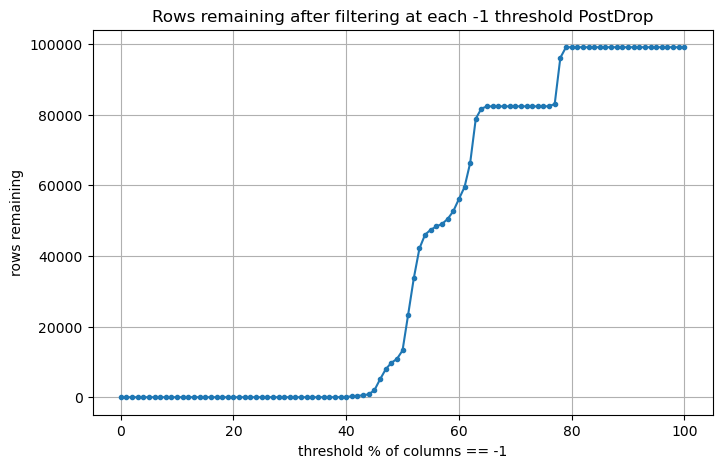

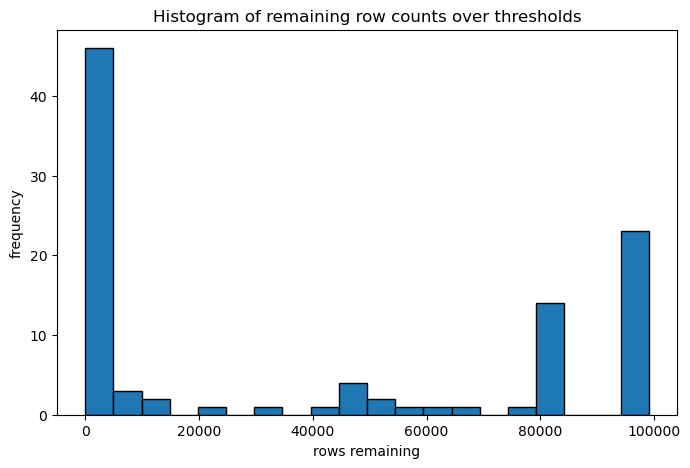

In [8]:
df_clean = filter_rows_by_negative_one_pct(data)

thresholds = np.linspace(0.0, 1.0, 101)
remaining_counts = []

for t in thresholds:
    df_tmp = filter_rows_by_negative_one_pct(data, threshold=t)
    remaining_counts.append(len(df_tmp))

print("data original shape:", data.shape)
print("rows remaining at thresholds (0..100%):", remaining_counts[:5], "...", remaining_counts[-5:])

plt.figure(figsize=(8, 5))
plt.plot(thresholds * 100, remaining_counts, marker="o", markersize=3)
plt.xlabel("threshold % of columns == -1")
plt.ylabel("rows remaining")
plt.title("Rows remaining after filtering at each -1 threshold PostDrop")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(remaining_counts, bins=20, edgecolor="k")
plt.xlabel("rows remaining")
plt.ylabel("frequency")
plt.title("Histogram of remaining row counts over thresholds")
plt.show()

In [9]:
data['PESEX'].value_counts(dropna=False)

PESEX
2    50665
1    48398
Name: count, dtype: int64

Looking into PWSSWGT as the main weight column

In [10]:
under18 = data[data['PRTAGE'] < 18]
#len(under18)
under18['PWSSWGT'] = under18['PWSSWGT'] / 10000
child_votes = under18[under18['PES1'] == 1]['PWSSWGT'].sum()
print(under18['PES1'].value_counts())
print(child_votes)

PES1
-1    20081
Name: count, dtype: int64
0.0


In [11]:
# eliminate under 18  
data = data[data['PRTAGE'] >= 18]
# edit weight (PWSSWGT) to have correct decimal placement
data['PWSSWGT'] = data['PWSSWGT'] / 10000

In [12]:
# count of voters? 
nvoters = data[data['PES1'] == 1]['PWSSWGT'].sum()
print(f"Estimated voters: {nvoters:,.0f}")
print("Total vote count in the 2024 Presidential election was about 155 million")

Estimated voters: 154,307,706
Total vote count in the 2024 Presidential election was about 155 million


In [13]:
turnout_sex = (
    data.groupby(['PESEX', 'PES1'])['PWSSWGT']
    .sum()
    .unstack()
)
print(turnout_sex)
# PESEX: 1 = male, 2 = female
# PES1 (vote?): 1 = yes, 2 = no

PES1             -3            -2            -1             1             2
PESEX                                                                      
1      1.659425e+06  2.170948e+06  2.510079e+07  7.277608e+07  2.501910e+07
2      1.870221e+06  1.805289e+06  2.496904e+07  8.153163e+07  2.346062e+07


In [14]:
turnout_males = turnout_sex[1][1] / turnout_sex.loc[1].sum()
turnout_females = turnout_sex[1][2] / turnout_sex.loc[2].sum()
print(f"Male Turnout: {turnout_males}")
print(f"Female Turnout: {turnout_females}")
print("woohoo")

Male Turnout: 0.5742774148246865
Female Turnout: 0.6100986467359265
woohoo


In [15]:
data['PRTAGE'].value_counts()

PRTAGE
80    2672
85    2180
64    1371
61    1365
62    1362
      ... 
74    1011
75     996
76     988
78     817
79     635
Name: count, Length: 64, dtype: int64

Model attempt

Removing useless allocation flags before fitting

In [16]:
bad_cols = [col for col in data.columns if col.startswith(('PX', 'HX'))]
data_cleaner = data.drop(columns= bad_cols)
print(f"Remaining columns: {len(data_cleaner.columns)}")

Remaining columns: 299


In [17]:
data_cleaner['voted'] = (data_cleaner['PES1']==1).astype(int)

C:\Users\chris\AppData\Local\Temp\ipykernel_21984\1787282179.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_cleaner['voted'] = (data_cleaner['PES1']==1).astype(int)


In [18]:
from sklearn.model_selection import train_test_split
import statsmodels.formula.api as smf

#train, test = train_test_split(
#    data, test_size = 0.3, random_state = 1848, stratify = data_cleaner['voted']
#)

#lg_model_0 = smf.logit(
#    formula= 'voted ~ PESEX + PRTAGE + PTDTRACE + PEEDUCA', data = train
#)
#result = lg_model_0.fit(
#    method = 'bfgs', var_weights = train['PWSSWGT'], disp=False
#)
#print(result.summary())

FAMD

In [ ]:
#%pip install prince

import prince

df_mixed = data_cleaner[['PRTAGE', 'PESEX', 'PEEDUCA', 'HEFAMINC']].copy()
df_mixed['PESEX'] = df_mixed['PESEX'].map({1: 'Male', 2: 'Female'})

#if you don't do this it breaks
df_mixed['PESEX'] = df_mixed['PESEX'].astype('category')
df_mixed['PEEDUCA'] = df_mixed['PEEDUCA'].astype('category')
df_mixed['PRTAGE'] = df_mixed['PRTAGE'].astype('float') 

famd = prince.FAMD(
    n_components=3,
    n_iter=3,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=42
).fit(df_mixed)

famd_components = famd.row_coordinates(df_mixed)
print(famd_components.head())



component         0         1         2
0          1.912566  0.003014 -1.136259
1          0.465914 -0.219416 -0.737491
2          0.567485 -0.170797 -0.518763
3         -0.927943 -0.543275  0.449137
4         -0.859197 -0.013825  0.433636


In [20]:
# Plotting the variables
ax = famd.plot(
    df_mixed,
    x_component=0,
    y_component=1,
    show_row_labels=False,
    show_column_labels=True
)


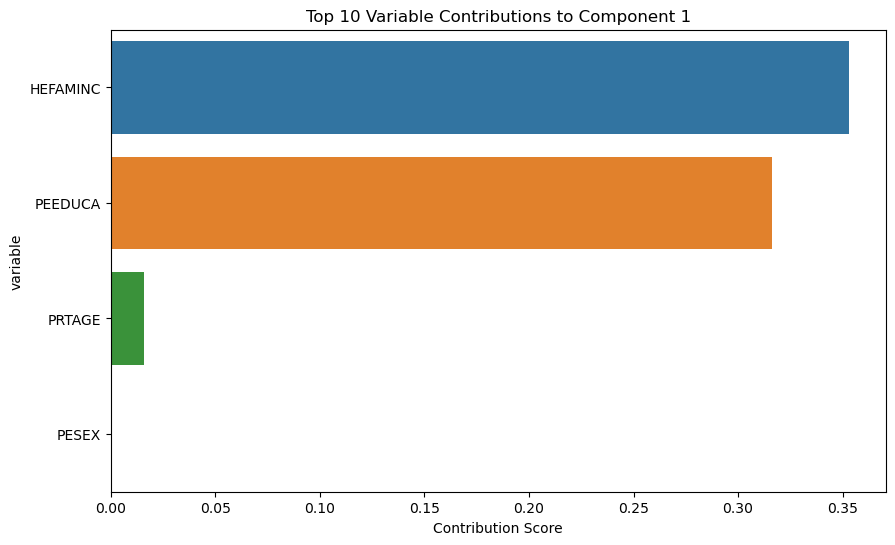

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get the contribution of each variable to the first component
contributions = famd.column_contributions_.sort_values(by=0, ascending=False)

# 2. Plot the top 10 contributors
plt.figure(figsize=(10, 6))
sns.barplot(x=contributions[0].head(10), y=contributions.index[:10])
plt.title('Top 10 Variable Contributions to Component 1')
plt.xlabel('Contribution Score')
plt.show()

FAMD 2. or MCA cause it's broken

In [29]:
vars_to_use = ['PRTAGE', 'PESEX', 'PEEDUCA', 'HEFAMINC', 'PTDTRACE', 'PEHRUSLT']
df_pca = data[vars_to_use + ['PWSSWGT']].copy()
df_pca = df_pca.replace(df_pca < 0).dropna()
#cat_vars = ['PESEX', 'PEEDUCA', 'PTDTRACE']
#num_vars = ['PRTAGE', 'HEFAMINC', 'PEHRUSLT']
#df_pca[num_vars] = df_pca[num_vars].astype(int)
#df_pca[cat_vars] = df_pca[cat_vars].astype(str)

df_pca['age_group'] = pd.cut(
    df_pca['PRTAGE'],
    bins = [18, 30, 45, 60, 75, 100],
    labels=['18-30', '31-45', '46-60', '61-75', '75+']
)

df_pca['hours_group'] = pd.cut(
    df_pca['PEHRUSLT'],
    bins=[0, 20, 34, 40, 60, 100],
    labels=['under20', '20-34', '35-40', '41-60', '60+']
)

df_pca['income_group'] = pd.cut(
    df_pca['HEFAMINC'],
    bins=[0, 7, 11, 14, 16],
    labels=['low', 'middle', 'upper-middle', 'high']
)

cat_vars = ['age_group', 'hours_group', 'income_group', 
            'PESEX', 'PEEDUCA', 'PTDTRACE']
df_pca[cat_vars] = df_pca[cat_vars].astype(str)
print(df_pca[cat_vars].dtypes)
print(df_pca.shape)

age_group       str
hours_group     str
income_group    str
PESEX           str
PEEDUCA         str
PTDTRACE        str
dtype: object
(78982, 10)


In [30]:
mca = prince.MCA(
    n_components = 5,
    random_state=1848
).fit(
    df_pca[cat_vars]
)
coords = mca.transform(df_pca[cat_vars])
coords.columns = [f"MC{i+1}" for i in range(coords.shape[1])]
print(coords.head())

        MC1       MC2       MC3       MC4       MC5
0 -0.038502  0.113812 -0.042752 -0.238594  0.000488
1 -0.038502  0.113812 -0.042752 -0.238594  0.000488
2 -0.038502  0.113812 -0.042752 -0.238594  0.000488
3 -0.119789 -0.566749 -0.256381  1.283692 -0.161418
4 -0.082321 -0.497442 -0.135831  1.123999 -0.072826


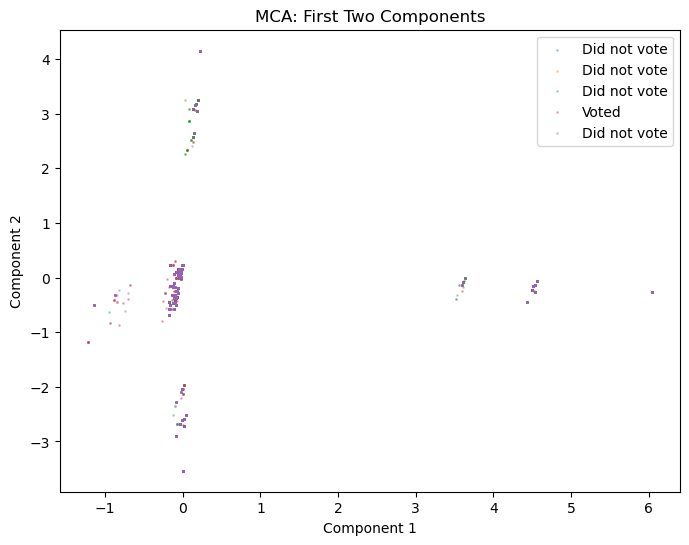

In [33]:
coords['voted'] = data.loc[df_pca.index, 'PES1'].values

fig, ax = plt.subplots(figsize=(8, 6))
for label, group in coords.groupby('voted'):
    ax.scatter(
        group['MC1'], group['MC2'],
        label='Voted' if label == 1 else 'Did not vote',
        alpha=0.3, s=1
    )
ax.set_xlabel('Component 1')
ax.set_ylabel('Component 2')
ax.legend()
plt.title('MCA: First Two Components')
plt.show()

In [36]:
total_inertia = coords.var().sum()
component_inertia = coords.var()

variance_df = pd.DataFrame({
    'component':  [f"MC{i+1}" for i in range(coords.shape[1])],
    'variance':   (component_inertia / total_inertia).round(3),
    'cumulative': (component_inertia / total_inertia).cumsum().round(3)
})
print(variance_df)

      component  variance  cumulative
MC1         MC1     0.122       0.122
MC2         MC2     0.117       0.238
MC3         MC3     0.117       0.356
MC4         MC4     0.114       0.470
MC5         MC5     0.107       0.576
voted       MC6     0.424       1.000


In [38]:
print(coords.groupby('voted')[['MC1','MC2']].mean())

            MC1       MC2
voted                    
-3    -0.012907 -0.008659
-2    -0.043300 -0.062608
-1     0.084827  0.071579
 1    -0.032941 -0.011430
 2     0.061474 -0.043397
